# Music as a Sentiment Barometer
## Notebook 1 — Data Collection

**Research question:** Does public music preference reflect *consumer sentiment* (how people feel about the economy)?

**Three data sources:**
| Source | What | URL |
|---|---|---|
| HipsterVizNinja GitHub | Billboard Hot 100 chart positions 1958–present | Direct CSV |
| Kaggle (Sean Miller) | Spotify audio features per song, pre-scraped 1958–2017 | Download manually |
| FRED | Economic indicators + Michigan Consumer Sentiment | Free API key |

**Reference:** Extends Larson (2022) — *The Lure of Musical Comfort*, CMC Senior Thesis

In [35]:
# ── INSTALL ───────────────────────────────────────────────────────────────────
!pip install pandas-datareader --quiet

In [36]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


---
## Part 1 — Billboard Chart Data
**Source:** HipsterVizNinja GitHub — Billboard Hot 100 since 1958  
**Direct URL:** `https://raw.githubusercontent.com/HipsterVizNinja/random-data/main/Music/hot-100/Hot%20100.csv`

Read it directly into pandas.

In [37]:
# ── LOAD BILLBOARD DATA ───────────────────────────────────────────────────────
BILLBOARD_URL = (
    'https://raw.githubusercontent.com/HipsterVizNinja/'
    'random-data/main/Music/hot-100/Hot%20100.csv'
)

billboard = pd.read_csv(BILLBOARD_URL)

# Parse dates
billboard['chart_date'] = pd.to_datetime(billboard['chart_date'])
billboard['year']       = billboard['chart_date'].dt.year
billboard['month']      = billboard['chart_date'].dt.month
billboard['year_month'] = billboard['chart_date'].dt.to_period('M')

# Standardise song_id to lowercase for merging with Kaggle audio features
billboard['song_id_lower'] = billboard['song_id'].str.lower().str.strip()

print(f'Billboard shape : {billboard.shape}')
print(f'Date range      : {billboard.chart_date.min().date()} '
      f'to {billboard.chart_date.max().date()}')
print(f'Unique songs    : {billboard.song_id.nunique():,}')
billboard.head()

Billboard shape : (352283, 17)
Date range      : 1958-08-02 to 2025-12-27
Unique songs    : 32,477


,chart_position,chart_date,song,performer,song_id,instance,time_on_chart,consecutive_weeks,previous_week,peak_position,worst_position,chart_debut,chart_url,year,month,year_month,song_id_lower
0,84,1990-05-05,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,1,1,NaN,84,84,1990-05-05,https://www.billboard.com/charts/hot-100/1990-...,1990,5,1990-05,"""b"" girlsyoung and restless"
1,78,1990-05-12,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,2,2,84.0,78,84,1990-05-05,https://www.billboard.com/charts/hot-100/1990-...,1990,5,1990-05,"""b"" girlsyoung and restless"
2,68,1990-05-19,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,3,3,78.0,68,84,1990-05-05,https://www.billboard.com/charts/hot-100/1990-...,1990,5,1990-05,"""b"" girlsyoung and restless"
3,60,1990-05-26,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,4,4,68.0,60,84,1990-05-05,https://www.billboard.com/charts/hot-100/1990-...,1990,5,1990-05,"""b"" girlsyoung and restless"
4,58,1990-06-02,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,5,5,60.0,58,84,1990-05-05,https://www.billboard.com/charts/hot-100/1990-...,1990,6,1990-06,"""b"" girlsyoung and restless"


---
## Part 2 — Spotify Audio Features

Because Spotify deprecated its Audio Features API in November 2024, we use a pre-scraped dataset hosted by the TidyTuesday project (R for Data Science community). This dataset was compiled from the Sean Miller Billboard + Spotify archive before the API was restricted, and is loaded directly via URL — no download or login required.

**Source:**
https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-09-14/audio_features.csv

**Coverage:**
29,503 unique songs matched to Billboard Hot 100 entries, 1958–2021


**Columns used:** `SongID`, `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`

In [38]:
audio = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/'
    'master/data/2021/2021-09-14/audio_features.csv'
)
print(f'Shape  : {audio.shape}')
print(f'Columns: {list(audio.columns)}')
audio.head(3)

Shape  : (29503, 22)
Columns: ['song_id', 'performer', 'song', 'spotify_genre', 'spotify_track_id', 'spotify_track_preview_url', 'spotify_track_duration_ms', 'spotify_track_explicit', 'spotify_track_album', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'spotify_track_popularity']


,song_id,performer,song,spotify_genre,spotify_track_id,spotify_track_preview_url,spotify_track_duration_ms,spotify_track_explicit,spotify_track_album,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity
0,-twistin'-White Silver SandsBill Black's Combo,Bill Black's Combo,-twistin'-White Silver Sands,[],NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,¿Dònde Està Santa Claus? (Where Is Santa Claus...,Augie Rios,¿Dònde Està Santa Claus? (Where Is Santa Claus?),['novelty'],NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,......And Roses And RosesAndy Williams,Andy Williams,......And Roses And Roses,"['adult standards', 'brill building pop', 'eas...",3tvqPPpXyIgKrm4PR9HCf0,https://p.scdn.co/mp3-preview/cef4883cfd1e0e53...,166106.0,False,The Essential Andy Williams,0.154,...,-14.063,1.0,0.0315,0.911,0.000267,0.112,0.15,83.969,4.0,38.0


In [39]:
# ── STANDARDISE COLUMN NAMES ──────────────────────────────────────────────────
# Normalise to lowercase and strip whitespace for safe merging

audio['song_id_lower'] = audio['song_id'].str.lower().str.strip()

# Keep only essential audio feature columns
AUDIO_COLS = [
    'song_id_lower', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'spotify_track_duration_ms'
]
audio_clean = audio[AUDIO_COLS].drop_duplicates('song_id_lower')

# Drop rows where all audio features are NaN (songs Spotify couldn't match)
audio_clean = audio_clean.dropna(subset=['valence', 'danceability', 'tempo'])

print(f'Songs with valid audio features: {len(audio_clean):,}')
audio_clean.head(3)

Songs with valid audio features: 24,224


,song_id_lower,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spotify_track_duration_ms
2,......and roses and rosesandy williams,0.154,0.185,5.0,-14.063,1.0,0.0315,0.91100,0.000267,0.112,0.150,83.969,166106.0
3,...and then there were drumssandy nelson,0.588,0.672,11.0,-17.278,0.0,0.0361,0.00256,0.745000,0.145,0.801,121.962,172066.0
4,...baby one more timebritney spears,0.759,0.699,0.0,-5.745,0.0,0.0307,0.20200,0.000131,0.443,0.907,92.960,211066.0


These audio features serve as the musical dependent variables in our analysis. Each feature captures a distinct sonic characteristic of a song — for example, `valence` measures musical happiness, `danceability` reflects rhythmic energy, and `tempo` captures pace.

By tracking how these features shift on a monthly basis across the Billboard Hot 100, we can test whether consumer music preferences respond to changes in economic conditions (hard indicators like unemployment and inflation) or to how people perceive the economy (the Michigan Consumer Sentiment Index). If music truly acts as an emotional barometer, we would expect features like `valence` and `danceability` to show stronger correlation with sentiment than with the raw economic data.

In [40]:
# ── MERGE Billboard + Audio Features ─────────────────────────────────────────
df = billboard.merge(audio_clean, on='song_id_lower', how='inner')

print(f'Merged shape : {df.shape}')
print(f'Match rate   : {len(df)/len(billboard)*100:.1f}% of chart entries matched')
print(f'Date range   : {df.chart_date.min().date()} to {df.chart_date.max().date()}')

# Save checkpoint
df.to_csv('billboard_audio_merged.csv', index=False)
print('\nSaved: billboard_audio_merged.csv ✓')
df.head(3)

Merged shape : (285614, 29)
Match rate   : 81.1% of chart entries matched
Date range   : 1958-08-02 to 2025-08-09

Saved: billboard_audio_merged.csv ✓


,chart_position,chart_date,song,performer,song_id,instance,time_on_chart,consecutive_weeks,previous_week,peak_position,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,spotify_track_duration_ms
0,84,1990-05-05,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,1,1,NaN,84,...,7.0,-11.913,1.0,0.439,0.016,0.0,0.312,0.769,193.762,242106.0
1,78,1990-05-12,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,2,2,84.0,78,...,7.0,-11.913,1.0,0.439,0.016,0.0,0.312,0.769,193.762,242106.0
2,68,1990-05-19,"""B"" Girls",Young And Restless,"""B"" GirlsYoung And Restless",1,3,3,78.0,68,...,7.0,-11.913,1.0,0.439,0.016,0.0,0.312,0.769,193.762,242106.0


---
## Part 3 — Economic Data from FRED


**Series we pull:**
| FRED Code | Name | Type |
|---|---|---|
| `UNRATE` | Unemployment Rate | Hard indicator |
| `CPIAUCSL` | CPI (Inflation) | Hard indicator |
| `A191RL1Q225SBEA` | Real GDP Growth (quarterly) | Hard indicator |
| `UMCSENT` | **Michigan Consumer Sentiment** | **Sentiment ← key variable** |
| `CSCICP03USM665S` | Conference Board Consumer Confidence | Sentiment (robustness) |

In [41]:
# ── FRED API KEY ──────────────────────────────────────────
FRED_API_KEY = '5445de2c678853d5f527145520cb9e0d '

START = '1958-01-01'
END   = '2024-12-31'

FRED_SERIES = {
    'unemployment':         'UNRATE',
    'cpi':                  'CPIAUCSL',
    'gdp_growth':           'A191RL1Q225SBEA',
    'michigan_sentiment':   'UMCSENT',          # original variable
    'conf_board_sentiment': 'CSCICP03USM665S',  # robustness check
    'recession':            'USREC',
}

import time
import pandas_datareader.data as web

frames = {}
for name, code in FRED_SERIES.items():
    for attempt in range(3):  # retry up to 3 times
        try:
            s = web.DataReader(code, 'fred', START, END, api_key=FRED_API_KEY)
            s.columns = [name]
            frames[name] = s
            print(f'  ✓  {name:30s} {len(s):5d} observations')
            time.sleep(1)  # small pause between requests
            break
        except Exception as e:
            print(f'  ✗  attempt {attempt+1} failed for {name}: {e}')
            time.sleep(3)  # longer pause before retry

print(f'\nSuccessfully pulled: {list(frames.keys())}')

# Combine and resample to monthly (GDP is quarterly — forward fill)
econ = pd.concat(frames.values(), axis=1)
econ = econ.resample('MS').first().ffill()
econ.index.name = 'date'
econ = econ.reset_index()
econ['year_month'] = pd.to_datetime(econ['date']).dt.to_period('M')

# ── Okun Misery Index (replicates Larson 2022) ────────────────────────────────
econ['inflation']    = econ['cpi'].pct_change(12) * 100
econ['misery_index'] = econ['unemployment'] + econ['inflation']

print(f'\nEconomic data shape: {econ.shape}')
print(f'Date range: {econ.date.min().date()} to {econ.date.max().date()}')
econ.tail()

  ✓  unemployment                     804 observations
  ✓  cpi                              804 observations
  ✓  gdp_growth                       268 observations
  ✓  michigan_sentiment               804 observations
  ✓  conf_board_sentiment             769 observations
  ✗  attempt 1 failed for recession: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)
  ✗  attempt 2 failed for recession: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)
  ✓  recession                        804 observations

Successfully pulled: ['unemployment', 'cpi', 'gdp_growth', 'michigan_sentiment', 'conf_board_sentiment', 'recession']

Economic data shape: (804, 10)
Date range: 1958-01-01 to 2024-12-01


,date,unemployment,cpi,gdp_growth,michigan_sentiment,conf_board_sentiment,recession,year_month,inflation,misery_index
799,2024-08-01,4.2,314.062,3.3,67.9,98.91297,0,2024-08,2.607144,6.807144
800,2024-09-01,4.1,314.732,3.3,70.1,98.91297,0,2024-09,2.426483,6.526483
801,2024-10-01,4.1,315.631,1.9,70.5,98.91297,0,2024-10,2.578844,6.678844
802,2024-11-01,4.2,316.528,1.9,71.8,98.91297,0,2024-11,2.719472,6.919472
803,2024-12-01,4.1,317.604,1.9,74.0,98.91297,0,2024-12,2.870691,6.970691


---
## Part 4 — Build Final Dataset

Aggregate audio features to **monthly averages** (same method as Larson 2022)  
then merge with economic data.

In [42]:
# ── MONTHLY AVERAGE AUDIO FEATURES ───────────────────────────────────────────
FEATURE_COLS = [
    'danceability', 'energy', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms'
]
# Only use columns that made it through the merge
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

monthly_music = (
    df.groupby('year_month')[FEATURE_COLS]
    .mean()
    .reset_index()
)
monthly_music['year_month'] = monthly_music['year_month'].astype(str)
econ['year_month']          = econ['year_month'].astype(str)

# ── FINAL MERGE ───────────────────────────────────────────────────────────────
final_df = monthly_music.merge(econ, on='year_month', how='inner')
final_df['year'] = pd.to_datetime(final_df['year_month']).dt.year

print(f"'recession' in final_df: {'recession' in final_df.columns}")
print(final_df[['year_month', 'recession']].tail())


'recession' in final_df: True
    year_month  recession
787    2024-03          0
788    2024-04          0
789    2024-05          0
790    2024-11          0
791    2024-12          0


In [43]:
# Drop rows missing sentiment data (Michigan index only starts 1978)
final_df_full    = final_df.copy()                       # keep full range for Larson replication
final_df_sent    = final_df.dropna(subset=['michigan_sentiment'])  # for sentiment model

print(f'Full dataset (1958–2017)     : {len(final_df_full):,} months')
print(f'Sentiment dataset (1978–2017): {len(final_df_sent):,} months')
print(f'Missing values:\n{final_df_full.isnull().sum()[final_df_full.isnull().sum() > 0]}')

# ── SAVE ─────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/side_proj/billboard_audio_merged.csv', index=False)
print('Saved: billboard_audio_merged.csv')


final_df_full.to_csv('/content/drive/MyDrive/side_proj/final_dataset_full.csv', index=False)
final_df_sent.to_csv('/content/drive/MyDrive/side_proj/final_dataset_sentiment.csv', index=False)
print('\nSaved:')
print('  final_dataset_full.csv      — use for Larson replication (Notebook 3a)')
print('  final_dataset_sentiment.csv — use for sentiment model    (Notebook 3b)')
final_df_full.head()

Full dataset (1958–2017)     : 792 months
Sentiment dataset (1978–2017): 792 months
Missing values:
conf_board_sentiment    17
inflation                5
misery_index             5
dtype: int64
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: billboard_audio_merged.csv

Saved:
  final_dataset_full.csv      — use for Larson replication (Notebook 3a)
  final_dataset_sentiment.csv — use for sentiment model    (Notebook 3b)


,year_month,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,date,unemployment,cpi,gdp_growth,michigan_sentiment,conf_board_sentiment,recession,inflation,misery_index,year
0,1958-08,0.571869,0.480261,-10.903519,0.915301,0.056605,0.656471,0.052686,0.194888,0.711180,...,1958-08-01,7.4,28.94,9.6,80.9,NaN,0,NaN,NaN,1958
1,1958-09,0.558049,0.464240,-10.970781,0.927083,0.045172,0.648226,0.064964,0.197364,0.692153,...,1958-09-01,7.1,28.91,9.6,80.9,NaN,0,NaN,NaN,1958
2,1958-10,0.550866,0.473740,-10.567072,0.920690,0.045625,0.684122,0.050387,0.199028,0.672169,...,1958-10-01,6.7,28.91,9.7,80.9,NaN,0,NaN,NaN,1958
3,1958-11,0.530650,0.470808,-10.723689,0.836842,0.052834,0.673205,0.064853,0.188049,0.657755,...,1958-11-01,6.2,28.95,9.7,90.8,NaN,0,NaN,NaN,1958
4,1958-12,0.515868,0.466501,-10.880734,0.815789,0.054832,0.692490,0.082031,0.189436,0.638957,...,1958-12-01,6.2,28.97,9.7,90.8,NaN,0,NaN,NaN,1958


In [44]:
import pandas_datareader.data as web
test = web.DataReader('USREC', 'fred', '1958-01-01', '2024-12-31', api_key=FRED_API_KEY)
print(test.tail())

            USREC
DATE             
2024-08-01      0
2024-09-01      0
2024-10-01      0
2024-11-01      0
2024-12-01      0


In [45]:
# Confirm 'recession' appears in the output
print(final_df_full.columns.tolist())

# Save again

final_df_full.to_csv('final_dataset_full.csv', index=False)
final_df_sent.to_csv('final_dataset_sentiment.csv', index=False)

['year_month', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'date', 'unemployment', 'cpi', 'gdp_growth', 'michigan_sentiment', 'conf_board_sentiment', 'recession', 'inflation', 'misery_index', 'year']


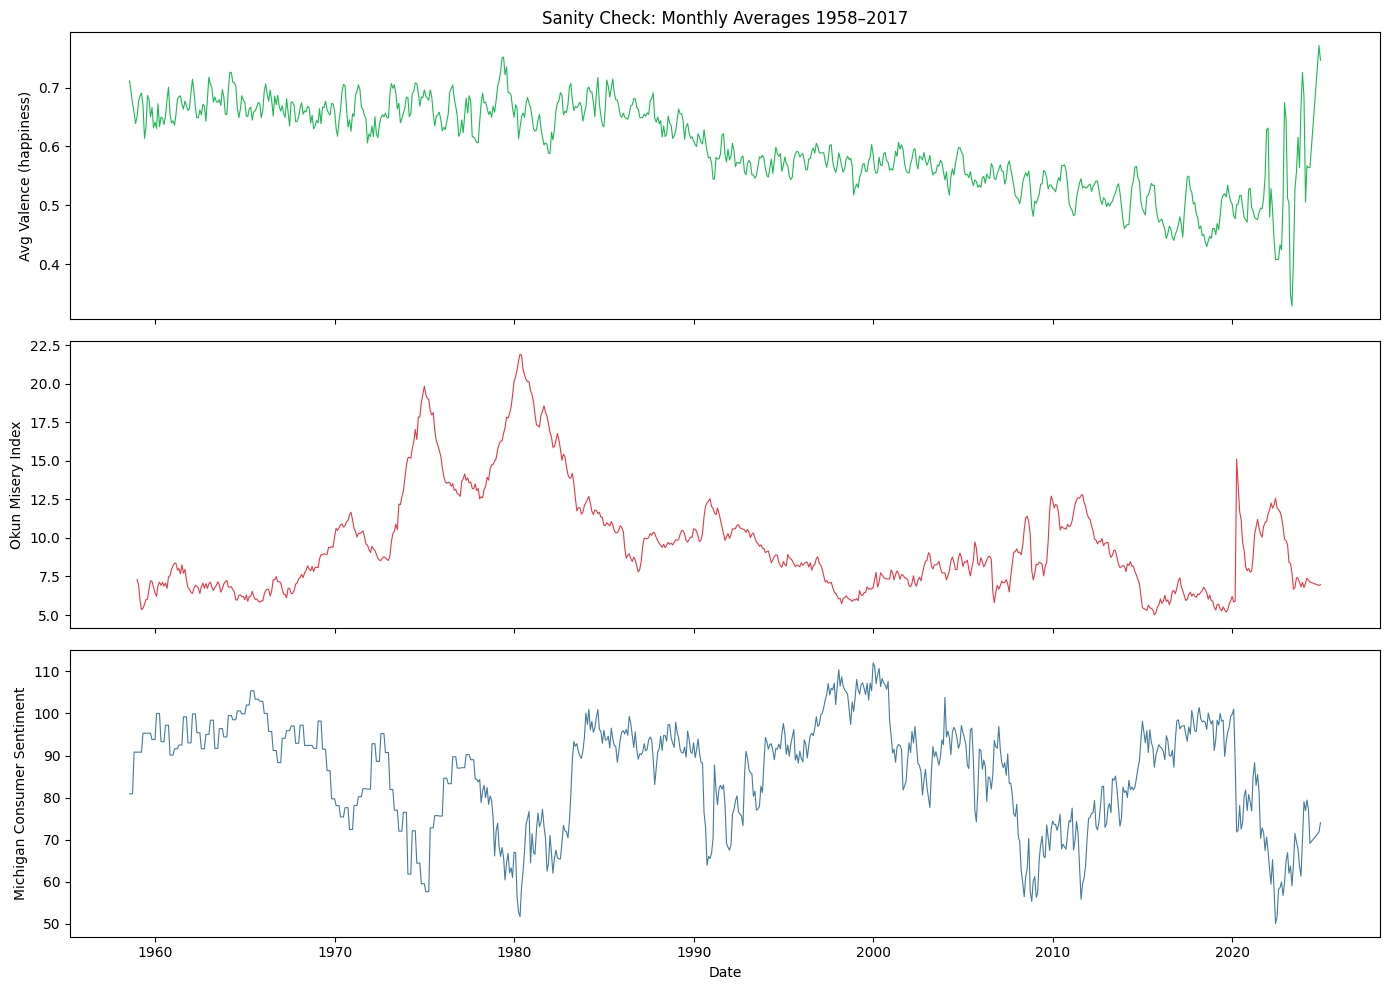

In [46]:
# ── SANITY CHECK ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(pd.to_datetime(final_df_full['year_month']),
             final_df_full['valence'], color='#1DB954', linewidth=0.8)
axes[0].set_ylabel('Avg Valence (happiness)')
axes[0].set_title('Sanity Check: Monthly Averages 1958–2017')

axes[1].plot(pd.to_datetime(final_df_full['year_month']),
             final_df_full['misery_index'], color='#E63946', linewidth=0.8)
axes[1].set_ylabel('Okun Misery Index')

axes[2].plot(pd.to_datetime(final_df_sent['year_month']),
             final_df_sent['michigan_sentiment'], color='#457B9D', linewidth=0.8)
axes[2].set_ylabel('Michigan Consumer Sentiment')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary — What we now have

| File | Use in |
|---|---|
| `billboard_audio_merged.csv` | Raw merged data — backup |
| `final_dataset_full.csv` | Notebook 3a — replicate Larson (2022) baseline |
| `final_dataset_sentiment.csv` | Notebook 3b — YOUR sentiment model (1978–2017) |

**Core hypothesis you are testing:**
> Monthly averages of Billboard audio features (valence, danceability, tempo)  
> correlate more strongly with **Michigan Consumer Sentiment** than with  
> Okun's **Misery Index** — music is an emotional barometer, not an economic one.
